# DE 2 - Regresión con Random Forest

## Justificación

Uso Random Forest como alternativa a los modelos lineales de SA. La búsqueda ajusta número de árboles, profundidad y tamaño mínimo de hoja.

## Diseño del modelo

El proceso está ordenado en celdas: carga, preparación, ajuste, evaluación y guardado del modelo.


In [ ]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split

ruta = Path("..")
datos = pd.read_csv(ruta / "data" / "beisbol.csv")
datos = datos.drop(columns=["Unnamed: 0"])

x = datos[["bateos"]]
y = datos["runs"]

x_entrena, x_prueba, y_entrena, y_prueba = train_test_split(
    x, y, test_size=0.25, random_state=42
)

## Entrenamiento y búsqueda

In [ ]:
bosque = RandomForestRegressor(random_state=42)
validacion = KFold(n_splits=5, shuffle=True, random_state=42)

busqueda = GridSearchCV(
    bosque,
    {
        "n_estimators": [100, 300],
        "max_depth": [None, 3, 6],
        "min_samples_leaf": [1, 2, 3],
    },
    cv=validacion,
    scoring="neg_root_mean_squared_error",
)
busqueda.fit(x_entrena, y_entrena)
busqueda.best_params_

## Evaluación

In [ ]:
prediccion = busqueda.predict(x_prueba)

resultado = pd.Series({
    "MAE": mean_absolute_error(y_prueba, prediccion),
    "RMSE": mean_squared_error(y_prueba, prediccion) ** 0.5,
    "R2": r2_score(y_prueba, prediccion),
})
resultado

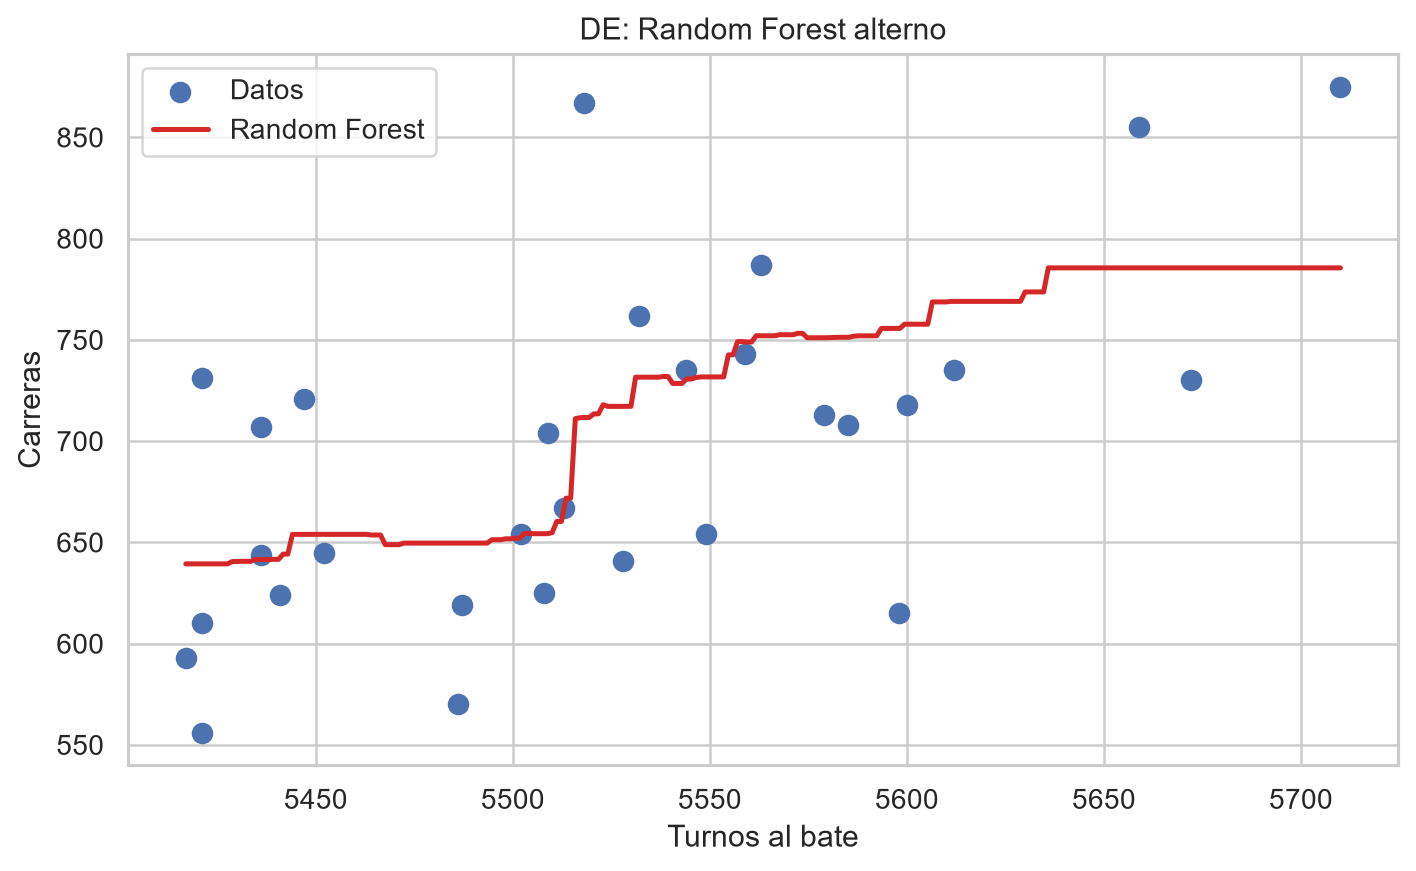

In [ ]:
eje = pd.DataFrame({
    "bateos": np.linspace(datos["bateos"].min(), datos["bateos"].max(), 200)
})

plt.figure(figsize=(8, 5))
plt.scatter(datos["bateos"], datos["runs"], label="Datos")
plt.plot(eje["bateos"], busqueda.predict(eje), color="red", label="Random Forest")
plt.xlabel("Turnos al bate")
plt.ylabel("Carreras")
plt.title("Random Forest")
plt.legend()
plt.show()

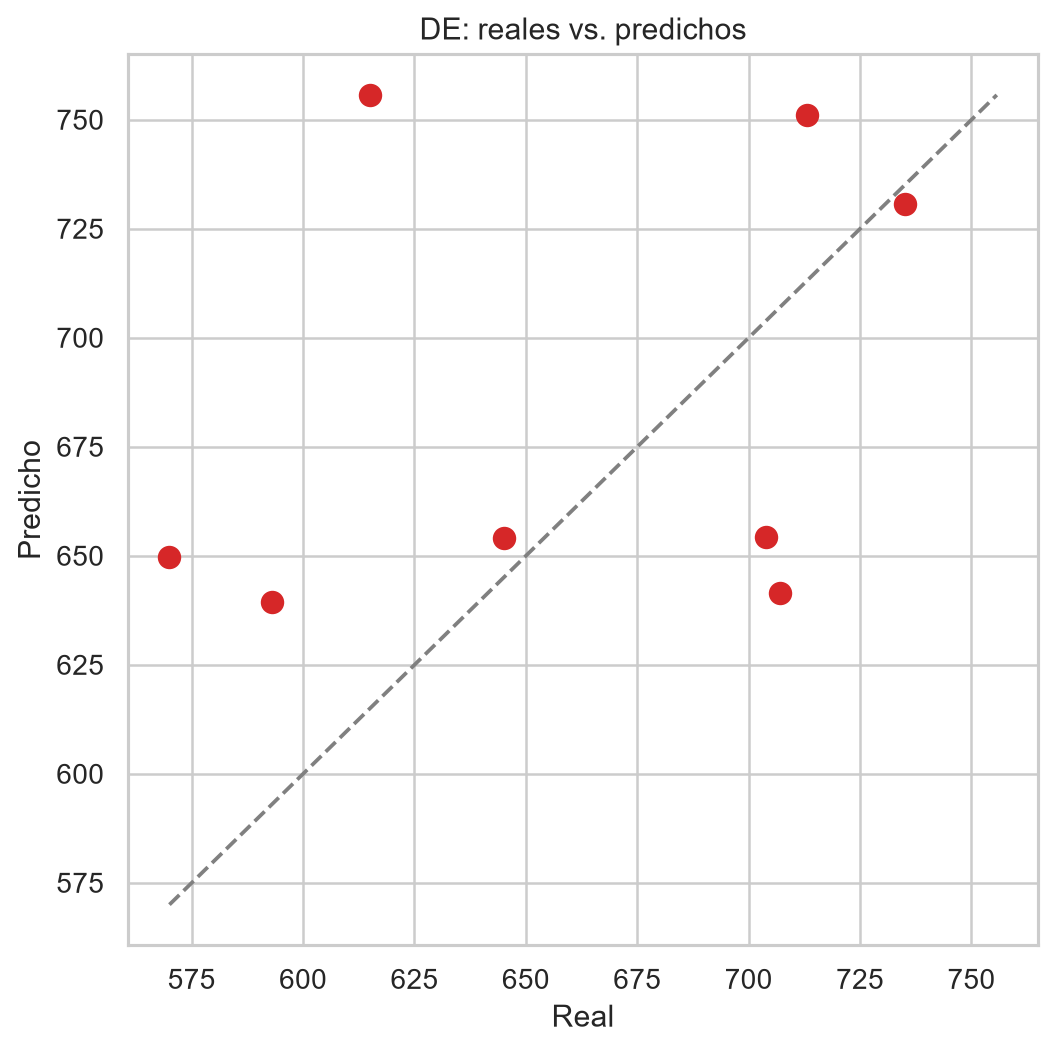

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_prueba, prediccion)
minimo = min(y_prueba.min(), prediccion.min())
maximo = max(y_prueba.max(), prediccion.max())
plt.plot([minimo, maximo], [minimo, maximo], "--", color="gray")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Valores reales contra predichos")
plt.show()

In [ ]:
joblib.dump(busqueda.best_estimator_, ruta / "models" / "de_random_forest_beisbol.joblib")

## Interpretación

El modelo sigue teniendo R² negativo. El conjunto solo contiene 30 equipos y un predictor, por lo que el bosque no logra generalizar mejor que una referencia basada en la media.